# Big Data UTS — Analisis Iklim BMKG (FINAL)
**Dataset:** Laporan Iklim Harian BMKG — Stasiun Meteorologi Juanda  
**Periode:** Maret 2025 – Maret 2026  
**Kolom:** TN, TX, TAVG, RH_AVG, RR, SS, FF_X, DDD_X, FF_AVG, DDD_CAR

---
| Cell | Tahap |
|------|-------|
| 1 | Install & Import Library |
| 2 | Mount Google Drive |
| 3 | Upload File XLSX (termasuk file revisi Maret 2026) |
| 4 | **Data Preparation** — Merge semua file |
| 5 | **Data Preparation** — Standardization |
| 6 | **Data Preparation** — Cleaning |
| 7 | **Data Preparation** — Handling Missing Values |
| 8 | **EDA** — Statistik Deskriptif |
| 9 | **EDA** — Distribution Analysis |
| 10 | **EDA** — Initial Patterns |
| 11 | **Analysis** — Trend Analysis |
| 12 | **Analysis** — Stasiun & Parameter Analysis |
| 13 | **Analysis** — Seasonal Analysis |
| 14 | **Analysis** — Anomaly & Extreme Events |
| 15 | **Analysis** — Geographic Analysis |
| 16 | **Visualizations** — Time Series Charts |
| 17 | **Visualizations** — Bar Charts |
| 18 | **Visualizations** — Heatmaps |
| 19 | **Visualizations** — Correlation & Network Diagram |
| 20 | Export Hasil ke Excel |

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL & IMPORT LIBRARY                          ║
# ╚══════════════════════════════════════════════════════════════╝

!pip install openpyxl networkx --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import networkx as nx
import glob, os, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.size']        = 10
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_palette('Set2')

print('Library berhasil diimport!')
print(f'  pandas   : {pd.__version__}')
print(f'  numpy    : {np.__version__}')
print(f'  seaborn  : {sns.__version__}')
print(f'  networkx : {nx.__version__}')

Library berhasil diimport!
  pandas   : 2.2.2
  numpy    : 2.0.2
  seaborn  : 0.13.2
  networkx : 3.6.1


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — MOUNT GOOGLE DRIVE                                ║
# ╚══════════════════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/big-data-uts'
os.makedirs(f'{PROJECT_DIR}/data',        exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/output',      exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/visualisasi', exist_ok=True)

print('Folder siap di Google Drive!')
print(f'  {PROJECT_DIR}/data')
print(f'  {PROJECT_DIR}/output')
print(f'  {PROJECT_DIR}/visualisasi')

Mounted at /content/drive
Folder siap di Google Drive!
  /content/drive/MyDrive/big-data-uts/data
  /content/drive/MyDrive/big-data-uts/output
  /content/drive/MyDrive/big-data-uts/visualisasi


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — UPLOAD FILE XLSX KE GOOGLE DRIVE                  ║
# ║  CATATAN: File maret 2026 yang benar adalah                  ║
# ║           laporan_iklim_harian-Maret_2026.xlsx               ║
# ║           (11 kolom lengkap, bukan versi lama 3 kolom)       ║
# ╚══════════════════════════════════════════════════════════════╝

from google.colab import files
import shutil

print('Upload semua file laporan_iklim_*.xlsx (termasuk file revisi Maret 2026)...')
uploaded = files.upload()

DATA_DIR = f'{PROJECT_DIR}/data'

# Nama file lama maret 2026 yang salah — akan digantikan file baru
FILE_LAMA_MARET2026 = '1775380725583_laporan_iklim_maret_2026.xlsx'
FILE_BARU_MARET2026 = 'laporan_iklim_harian-Maret_2026.xlsx'

for filename in uploaded.keys():
    dest = f'{DATA_DIR}/{filename}'
    shutil.move(f'/content/{filename}', dest)
    print(f'  {filename} -> disimpan ke Google Drive')

# Hapus file lama maret 2026 jika ada
path_lama = f'{DATA_DIR}/{FILE_LAMA_MARET2026}'
if os.path.exists(path_lama):
    os.remove(path_lama)
    print(f'  [DIHAPUS] File lama: {FILE_LAMA_MARET2026}')

all_files = os.listdir(DATA_DIR)
print(f'\nTotal file di folder data: {len(all_files)} file')
for f in sorted(all_files):
    print(f'  {f}')

Upload semua file laporan_iklim_*.xlsx (termasuk file revisi Maret 2026)...


Saving laporan_iklim_harian-Maret 2026.xlsx to laporan_iklim_harian-Maret 2026.xlsx
Saving laporan_iklim_ juni 2025.xlsx to laporan_iklim_ juni 2025.xlsx
Saving laporan_iklim_Agustus 2025.xlsx to laporan_iklim_Agustus 2025.xlsx
Saving laporan_iklim_april 2025.xlsx to laporan_iklim_april 2025.xlsx
Saving laporan_iklim_desember 2025.xlsx to laporan_iklim_desember 2025.xlsx
Saving laporan_iklim_februari 2026.xlsx to laporan_iklim_februari 2026.xlsx
Saving laporan_iklim_januari 2026.xlsx to laporan_iklim_januari 2026.xlsx
Saving laporan_iklim_july 2025.xlsx to laporan_iklim_july 2025.xlsx
Saving laporan_iklim_maret 2025.xlsx to laporan_iklim_maret 2025.xlsx
Saving laporan_iklim_mei 2025.xlsx to laporan_iklim_mei 2025.xlsx
Saving laporan_iklim_november 2025.xlsx to laporan_iklim_november 2025.xlsx
Saving laporan_iklim_oktober2025.xlsx to laporan_iklim_oktober2025.xlsx
Saving laporan_iklim_september 2025.xlsx to laporan_iklim_september 2025.xlsx
  laporan_iklim_harian-Maret 2026.xlsx -> disi

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — DATA PREPARATION: MERGE SEMUA FILE XLSX           ║
# ║  Format file: 11 kolom (TN,TX,TAVG,RH_AVG,RR,SS,            ║
# ║               FF_X,DDD_X,FF_AVG,DDD_CAR)                    ║
# ╚══════════════════════════════════════════════════════════════╝

DATA_DIR   = f'{PROJECT_DIR}/data'
files_list = sorted(glob.glob(os.path.join(DATA_DIR, '*laporan_iklim*.xlsx')))

print(f'Ditemukan {len(files_list)} file:')
for f in files_list:
    print(f'  -> {os.path.basename(f)}')

# Kolom data untuk file 11-kolom
DATA_COLS = ['TANGGAL','TN','TX','TAVG','RH_AVG','RR','SS','FF_X','DDD_X','FF_AVG','DDD_CAR']

records = []
skipped = []

for filepath in files_list:
    filename = os.path.basename(filepath)
    raw = pd.read_excel(filepath, sheet_name='Worksheet', header=None)

    # Cek jumlah kolom — skip file 3-kolom (format lama/salah)
    if raw.shape[1] < 11:
        skipped.append(filename)
        print(f'  [SKIP] {filename} — hanya {raw.shape[1]} kolom (format tidak valid)')
        continue

    def extract_val(i):
        return str(raw.iloc[i, 2]).strip().replace(': ', '').replace(':  ', '').strip()

    id_wmo  = extract_val(0)
    stasiun = extract_val(1)
    lintang = extract_val(2)
    bujur   = extract_val(3)
    elevasi = extract_val(4)

    # Header ada di baris index 7, data mulai baris index 8
    data_rows = raw.iloc[8:39, :11].copy()
    data_rows.columns = DATA_COLS
    data_rows = data_rows.dropna(subset=['TANGGAL'])
    data_rows = data_rows[data_rows['TANGGAL'].astype(str).str.match(r'\d{2}-\d{2}-\d{4}', na=False)]

    data_rows['ID_WMO']      = id_wmo
    data_rows['STASIUN']     = stasiun
    data_rows['LINTANG']     = lintang
    data_rows['BUJUR']       = bujur
    data_rows['ELEVASI']     = elevasi
    data_rows['SUMBER_FILE'] = filename

    records.append(data_rows)

df_raw = pd.concat(records, ignore_index=True)

print(f'\nTotal baris setelah merge : {len(df_raw)}')
if skipped:
    print(f'File di-skip (format lama): {skipped}')
print(f'Kolom : {list(df_raw.columns)}')
df_raw.head()

Ditemukan 13 file:
  -> laporan_iklim_ juni 2025.xlsx
  -> laporan_iklim_Agustus 2025.xlsx
  -> laporan_iklim_april 2025.xlsx
  -> laporan_iklim_desember 2025.xlsx
  -> laporan_iklim_februari 2026.xlsx
  -> laporan_iklim_harian-Maret 2026.xlsx
  -> laporan_iklim_januari 2026.xlsx
  -> laporan_iklim_july 2025.xlsx
  -> laporan_iklim_maret 2025.xlsx
  -> laporan_iklim_mei 2025.xlsx
  -> laporan_iklim_november 2025.xlsx
  -> laporan_iklim_oktober2025.xlsx
  -> laporan_iklim_september 2025.xlsx

Total baris setelah merge : 396
Kolom : ['TANGGAL', 'TN', 'TX', 'TAVG', 'RH_AVG', 'RR', 'SS', 'FF_X', 'DDD_X', 'FF_AVG', 'DDD_CAR', 'ID_WMO', 'STASIUN', 'LINTANG', 'BUJUR', 'ELEVASI', 'SUMBER_FILE']


,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR,ID_WMO,STASIUN,LINTANG,BUJUR,ELEVASI,SUMBER_FILE
0,01-06-2025,25.4,33.5,29,82,9.8,8,4,91,2,W,96935,Stasiun Meteorologi Juanda,-7.38460,112.78330,3 Meter,laporan_iklim_ juni 2025.xlsx
1,02-06-2025,25.5,34.2,29.3,81,8888,4.4,4,90,2,NE,96935,Stasiun Meteorologi Juanda,-7.38460,112.78330,3 Meter,laporan_iklim_ juni 2025.xlsx
2,03-06-2025,26.3,34.8,29.8,77,0,6.8,4,99,2,E,96935,Stasiun Meteorologi Juanda,-7.38460,112.78330,3 Meter,laporan_iklim_ juni 2025.xlsx
3,04-06-2025,26.3,33.8,28.8,78,0.4,8,4,110,2,E,96935,Stasiun Meteorologi Juanda,-7.38460,112.78330,3 Meter,laporan_iklim_ juni 2025.xlsx
4,05-06-2025,25.5,35.5,29.7,74,0,7.1,4,106,2,E,96935,Stasiun Meteorologi Juanda,-7.38460,112.78330,3 Meter,laporan_iklim_ juni 2025.xlsx


In [ ]:
df.tail()

,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,...,BUJUR,ELEVASI,SUMBER_FILE,TAHUN,BULAN,HARI,NAMA_BULAN,DOY,ELEVASI_M,STASIUN_SHORT
391,2025-09-26,26.9,34.7,30.3,65,0.0,8.0,5,92,3,...,112.7833,3 Meter,laporan_iklim_september 2025.xlsx,2025,9,26,September,269,3.0,Juanda
392,2025-09-27,26.5,34.3,30.0,67,0.0,8.0,5,97,4,...,112.7833,3 Meter,laporan_iklim_september 2025.xlsx,2025,9,27,September,270,3.0,Juanda
393,2025-09-28,28.2,33.8,30.9,66,0.0,8.0,6,110,4,...,112.7833,3 Meter,laporan_iklim_september 2025.xlsx,2025,9,28,September,271,3.0,Juanda
394,2025-09-29,26.9,34.9,31.2,67,0.0,8.0,5,143,3,...,112.7833,3 Meter,laporan_iklim_september 2025.xlsx,2025,9,29,September,272,3.0,Juanda
395,2025-09-30,26.8,32.7,29.2,77,0.4,7.3,4,50,2,...,112.7833,3 Meter,laporan_iklim_september 2025.xlsx,2025,9,30,September,273,3.0,Juanda


In [ ]:
–––df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TANGGAL          396 non-null    datetime64[ns]
 1   TN               396 non-null    float64       
 2   TX               396 non-null    float64       
 3   TAVG             396 non-null    float64       
 4   RH_AVG           396 non-null    float64       
 5   RR               361 non-null    float64       
 6   SS               396 non-null    float64       
 7   FF_X             396 non-null    float64       
 8   DDD_X            396 non-null    float64       
 9   FF_AVG           396 non-null    float64       
 10  DDD_CAR          396 non-null    object        
 11  ID_WMO           396 non-null    object        
 12  STASIUN          396 non-null    object        
 13  LINTANG          396 non-null    float64       
 14  BUJUR            396 non-null    float64  

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — DATA PREPARATION: STANDARDIZATION                 ║
# ╚══════════════════════════════════════════════════════════════╝

df = df_raw.copy()

# Standardisasi tanggal
df['TANGGAL']    = pd.to_datetime(df['TANGGAL'], dayfirst=True, errors='coerce')
df['TAHUN']      = df['TANGGAL'].dt.year
df['BULAN']      = df['TANGGAL'].dt.month
df['HARI']       = df['TANGGAL'].dt.day
df['NAMA_BULAN'] = df['TANGGAL'].dt.strftime('%B')
df['DOY']        = df['TANGGAL'].dt.dayofyear

# Standardisasi semua kolom numerik iklim
num_cols = ['TN','TX','TAVG','RH_AVG','RR','SS','FF_X','DDD_X','FF_AVG']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Standardisasi koordinat
df['LINTANG']   = pd.to_numeric(df['LINTANG'], errors='coerce')
df['BUJUR']     = pd.to_numeric(df['BUJUR'],   errors='coerce')
df['ELEVASI_M'] = df['ELEVASI'].str.extract(r'(\d+\.?\d*)').astype(float)

# Standardisasi teks
df['STASIUN']     = df['STASIUN'].str.strip()
df['DDD_CAR']     = df['DDD_CAR'].astype(str).str.strip().str.upper()
df['STASIUN_SHORT'] = df['STASIUN'].str.replace('Stasiun Meteorologi ', '', regex=False)

print('Data Standardization selesai!')
print(f'  -> Tanggal    : datetime + TAHUN, BULAN, HARI, NAMA_BULAN, DOY')
print(f'  -> Numerik    : TN, TX, TAVG, RH_AVG, RR, SS, FF_X, DDD_X, FF_AVG')
print(f'  -> Teks       : STASIUN, DDD_CAR distandardisasi')
print()
df.dtypes

Data Standardization selesai!
  -> Tanggal    : datetime + TAHUN, BULAN, HARI, NAMA_BULAN, DOY
  -> Numerik    : TN, TX, TAVG, RH_AVG, RR, SS, FF_X, DDD_X, FF_AVG
  -> Teks       : STASIUN, DDD_CAR distandardisasi



,0
TANGGAL,datetime64[ns]
TN,float64
TX,float64
TAVG,float64
RH_AVG,int64
RR,float64
SS,float64
FF_X,int64
DDD_X,int64
FF_AVG,int64


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — DATA PREPARATION: CLEANING                        ║
# ╚══════════════════════════════════════════════════════════════╝

print(f'Jumlah baris sebelum cleaning : {len(df)}')

# Hapus duplikat
dup = df.duplicated(subset=['TANGGAL', 'STASIUN']).sum()
df  = df.drop_duplicates(subset=['TANGGAL', 'STASIUN'])
print(f'  -> Duplikat dihapus          : {dup} baris')

# Ganti kode error BMKG (8888, 9999) -> NaN untuk semua kolom numerik
num_cols = ['TN','TX','TAVG','RH_AVG','RR','SS','FF_X','DDD_X','FF_AVG']
total_8888 = 0
total_9999 = 0
for col in num_cols:
    m8 = df[col] == 8888
    m9 = df[col] == 9999
    total_8888 += m8.sum()
    total_9999 += m9.sum()
    df.loc[m8, col] = np.nan
    df.loc[m9, col] = np.nan
print(f'  -> Kode 8888 -> NaN          : {total_8888} nilai di semua kolom')
print(f'  -> Kode 9999 -> NaN          : {total_9999} nilai di semua kolom')

# Hapus baris tanggal tidak valid
invalid = df['TANGGAL'].isna().sum()
df = df.dropna(subset=['TANGGAL'])
print(f'  -> Tanggal invalid dihapus   : {invalid} baris')

# Validasi range logis
df.loc[df['TN'] < 0,  'TN']  = np.nan   # suhu min tidak mungkin < 0 di Indonesia
df.loc[df['TX'] > 45, 'TX']  = np.nan   # suhu max tidak mungkin > 45
df.loc[df['RR'] < 0,  'RR']  = np.nan   # curah hujan tidak mungkin negatif
df.loc[df['RH_AVG'] > 100, 'RH_AVG'] = np.nan
print(f'  -> Validasi range logis selesai')

print(f'\nJumlah baris setelah cleaning : {len(df)}')

Jumlah baris sebelum cleaning : 396
  -> Duplikat dihapus          : 0 baris
  -> Kode 8888 -> NaN          : 35 nilai di semua kolom
  -> Kode 9999 -> NaN          : 0 nilai di semua kolom
  -> Tanggal invalid dihapus   : 0 baris
  -> Validasi range logis selesai

Jumlah baris setelah cleaning : 396


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — DATA PREPARATION: HANDLING MISSING VALUES         ║
# ╚══════════════════════════════════════════════════════════════╝

num_cols = ['TN','TX','TAVG','RH_AVG','RR','SS','FF_X','FF_AVG']

print('Missing Values per Kolom (sebelum imputasi):')
mv_before = df[num_cols].isna().sum()
for col, n in mv_before.items():
    pct = n / len(df) * 100
    print(f'  {col:<10}: {n:>4} ({pct:.1f}%)')

df = df.sort_values(['STASIUN', 'TANGGAL']).reset_index(drop=True)

# Imputasi: Forward fill -> Backward fill -> Median per bulan
for col in num_cols:
    df[f'{col}_FILLED'] = df.groupby('STASIUN')[col].transform(lambda x: x.ffill().bfill())
    median_fill          = df.groupby(['STASIUN','BULAN'])[col].transform('median')
    df[f'{col}_FILLED']  = df[f'{col}_FILLED'].fillna(median_fill)

# Kolom flag khusus RR
df['RR_IMPUTED'] = df['RR'].isna() & df['RR_FILLED'].notna()

# Kategori intensitas hujan
bins   = [-0.1, 0, 5, 20, 50, 100, 150, 9999]
labels = ['Tidak Hujan','Sangat Ringan','Ringan','Sedang','Lebat','Sangat Lebat','Ekstrem']
df['KATEGORI_HUJAN'] = pd.cut(df['RR_FILLED'], bins=bins, labels=labels)

# Kategori suhu
df['KATEGORI_SUHU'] = pd.cut(df['TAVG_FILLED'],
    bins=[0, 24, 27, 30, 99],
    labels=['Sejuk (<24)', 'Normal (24-27)', 'Hangat (27-30)', 'Panas (>30)'])

print('\nMissing Values per Kolom (sesudah imputasi):')
mv_after = df[[f'{c}_FILLED' for c in num_cols]].isna().sum()
for col, n in mv_after.items():
    print(f'  {col:<15}: {n}')

print(f'\nMetode: Forward fill -> Backward fill -> Median per Bulan')
df[['TANGGAL','STASIUN_SHORT','TN','TX','TAVG','RR','RR_FILLED','RR_IMPUTED']].head(8)

Missing Values per Kolom (sebelum imputasi):
  TN        :    0 (0.0%)
  TX        :    0 (0.0%)
  TAVG      :    0 (0.0%)
  RH_AVG    :    0 (0.0%)
  RR        :   35 (8.8%)
  SS        :    0 (0.0%)
  FF_X      :    0 (0.0%)
  FF_AVG    :    0 (0.0%)

Missing Values per Kolom (sesudah imputasi):
  TN_FILLED      : 0
  TX_FILLED      : 0
  TAVG_FILLED    : 0
  RH_AVG_FILLED  : 0
  RR_FILLED      : 0
  SS_FILLED      : 0
  FF_X_FILLED    : 0
  FF_AVG_FILLED  : 0

Metode: Forward fill -> Backward fill -> Median per Bulan


,TANGGAL,STASIUN_SHORT,TN,TX,TAVG,RR,RR_FILLED,RR_IMPUTED
0,2025-03-01,Juanda,22.7,31.6,27.1,60.6,60.6,False
1,2025-03-02,Juanda,24.7,32.3,28.1,0.0,0.0,False
2,2025-03-03,Juanda,23.3,33.4,28.0,39.2,39.2,False
3,2025-03-04,Juanda,22.9,32.2,27.5,32.0,32.0,False
4,2025-03-05,Juanda,24.3,33.3,28.3,27.8,27.8,False
5,2025-03-06,Juanda,24.5,33.2,27.8,19.4,19.4,False
6,2025-03-07,Juanda,23.6,32.8,27.3,23.0,23.0,False
7,2025-03-08,Juanda,24.5,31.0,26.8,2.2,2.2,False


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — EDA: STATISTIK DESKRIPTIF                          ║
# ╚══════════════════════════════════════════════════════════════╝

filled_cols = ['TN_FILLED','TX_FILLED','TAVG_FILLED','RH_AVG_FILLED',
               'RR_FILLED','SS_FILLED','FF_X_FILLED','FF_AVG_FILLED']

print('='*65)
print('STATISTIK DESKRIPTIF SEMUA PARAMETER IKLIM')
print('='*65)
stat = df[filled_cols].describe().round(2)
stat.index.name = 'Statistik'
print(stat.to_string())

print('\n--- Rata-rata per Bulan ---')
monthly = df.groupby(['TAHUN','BULAN','NAMA_BULAN'])[filled_cols].mean().round(2).reset_index()
monthly.columns = ['TAHUN','BULAN','NAMA_BULAN'] + \
    ['TN','TX','TAVG','RH_AVG','RR','SS','FF_X','FF_AVG']
print(monthly.to_string(index=False))

print('\n--- Distribusi Kategori Hujan ---')
kat = df['KATEGORI_HUJAN'].value_counts()
for k, v in kat.items():
    print(f'  {str(k):<20}: {v:>4} hari  ({v/len(df)*100:.1f}%)')

print('\n--- Distribusi Arah Angin Terbanyak ---')
angin = df['DDD_CAR'].value_counts().head(8)
for k, v in angin.items():
    print(f'  {k:<5}: {v:>4} hari  ({v/len(df)*100:.1f}%)')

STATISTIK DESKRIPTIF SEMUA PARAMETER IKLIM
           TN_FILLED  TX_FILLED  TAVG_FILLED  RH_AVG_FILLED  RR_FILLED  SS_FILLED  FF_X_FILLED  FF_AVG_FILLED
Statistik                                                                                                    
count         396.00     396.00       396.00         396.00     396.00     396.00       396.00         396.00
mean           24.91      32.66        28.21          76.96       8.77       6.32         4.73           2.27
std             1.06       1.22         1.09           6.56      18.80       2.25         1.27           0.68
min            21.20      27.60        25.40          60.00       0.00       0.00         2.00           1.00
25%            24.30      31.80        27.50          72.00       0.00       5.00         4.00           2.00
50%            25.00      32.60        28.20          78.00       0.20       7.60         5.00           2.00
75%            25.60      33.40        28.80          82.00       9.65       

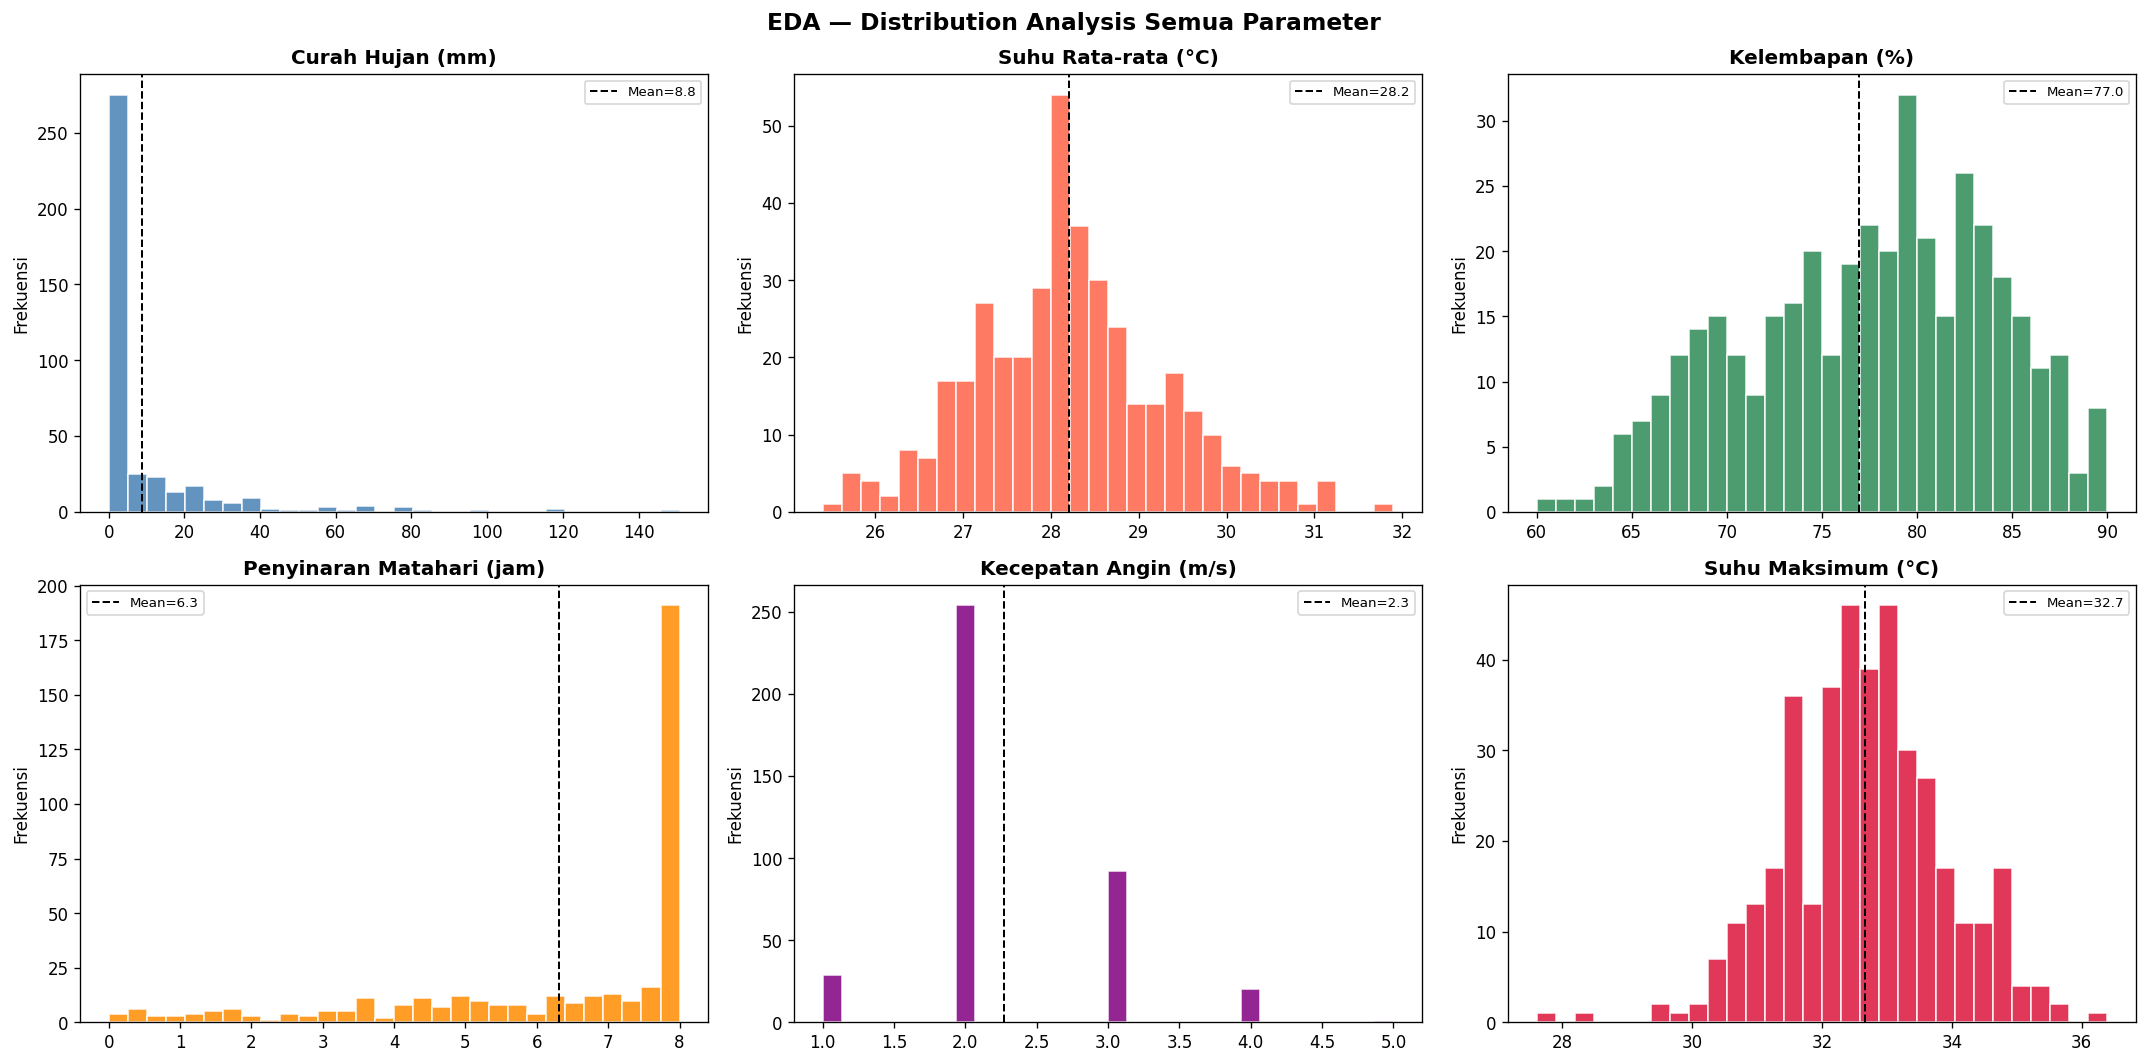

Distribution analysis selesai!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 9 — EDA: DISTRIBUTION ANALYSIS                         ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('EDA — Distribution Analysis Semua Parameter', fontsize=14, fontweight='bold')

params = [
    ('RR_FILLED',     'Curah Hujan (mm)',        'steelblue'),
    ('TAVG_FILLED',   'Suhu Rata-rata (°C)',      'tomato'),
    ('RH_AVG_FILLED', 'Kelembapan (%)',           'seagreen'),
    ('SS_FILLED',     'Penyinaran Matahari (jam)','darkorange'),
    ('FF_AVG_FILLED', 'Kecepatan Angin (m/s)',    'purple'),
    ('TX_FILLED',     'Suhu Maksimum (°C)',       'crimson'),
]

for ax, (col, label, color) in zip(axes.flatten(), params):
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean={df[col].mean():.1f}')
    ax.set_title(label)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/visualisasi/eda_distribution.png', bbox_inches='tight')
plt.show()
print('Distribution analysis selesai!')

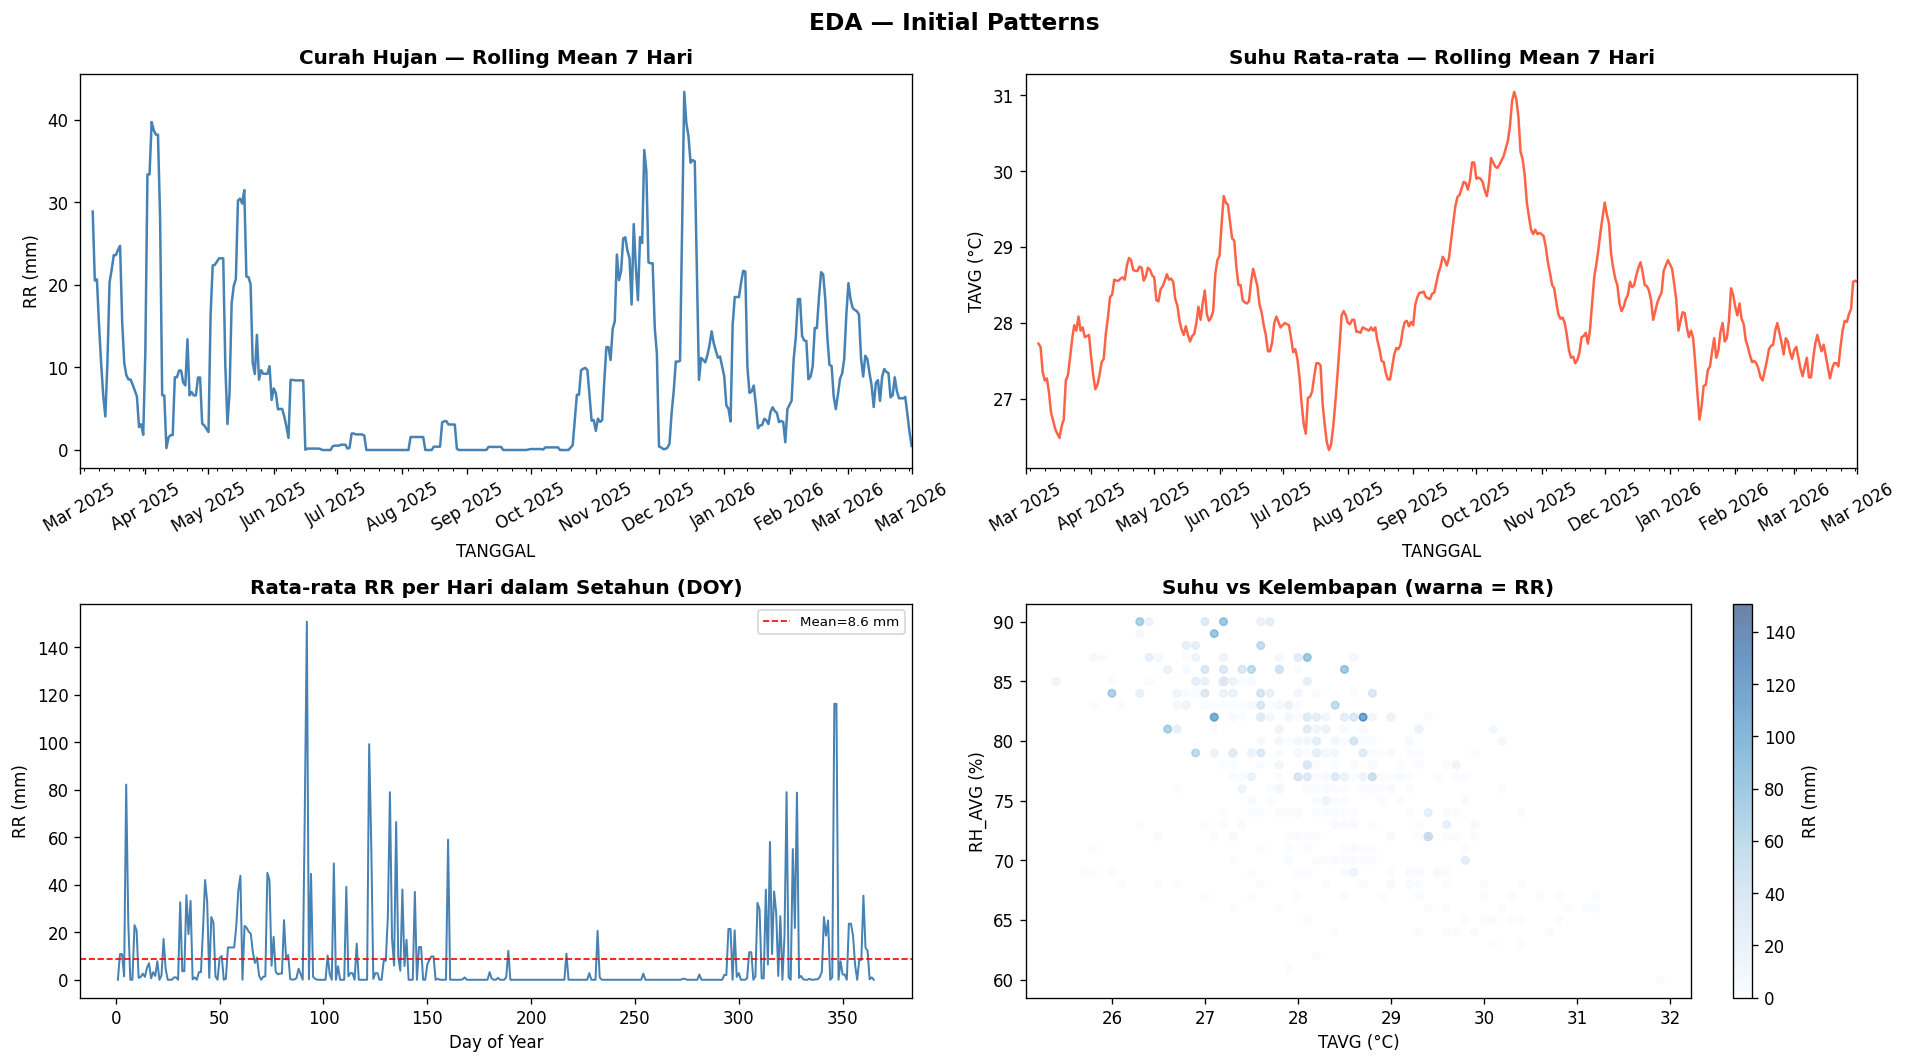

Initial patterns selesai!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 10 — EDA: INITIAL PATTERNS                            ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('EDA — Initial Patterns', fontsize=14, fontweight='bold')

df_sorted = df.sort_values('TANGGAL').set_index('TANGGAL')

# Rolling mean 7 hari: RR & TAVG
df_sorted['RR_FILLED'].rolling(7).mean().plot(ax=axes[0,0], color='steelblue', linewidth=1.5)
axes[0,0].set_title('Curah Hujan — Rolling Mean 7 Hari')
axes[0,0].set_ylabel('RR (mm)')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0,0].tick_params(axis='x', rotation=30)

df_sorted['TAVG_FILLED'].rolling(7).mean().plot(ax=axes[0,1], color='tomato', linewidth=1.5)
axes[0,1].set_title('Suhu Rata-rata — Rolling Mean 7 Hari')
axes[0,1].set_ylabel('TAVG (°C)')
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0,1].tick_params(axis='x', rotation=30)

# Rata-rata per DOY: RR
doy_avg = df.groupby('DOY')['RR_FILLED'].mean()
axes[1,0].plot(doy_avg.index, doy_avg.values, color='steelblue', linewidth=1.2)
axes[1,0].axhline(doy_avg.mean(), color='red', linestyle='--', linewidth=1,
                   label=f'Mean={doy_avg.mean():.1f} mm')
axes[1,0].set_title('Rata-rata RR per Hari dalam Setahun (DOY)')
axes[1,0].set_xlabel('Day of Year')
axes[1,0].set_ylabel('RR (mm)')
axes[1,0].legend(fontsize=8)

# Scatter: TAVG vs RH_AVG
sc = axes[1,1].scatter(df['TAVG_FILLED'], df['RH_AVG_FILLED'],
                        c=df['RR_FILLED'], cmap='Blues', alpha=0.6, s=20)
plt.colorbar(sc, ax=axes[1,1], label='RR (mm)')
axes[1,1].set_title('Suhu vs Kelembapan (warna = RR)')
axes[1,1].set_xlabel('TAVG (°C)')
axes[1,1].set_ylabel('RH_AVG (%)')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/visualisasi/eda_patterns.png', bbox_inches='tight')
plt.show()
print('Initial patterns selesai!')

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 11 — ANALYSIS: TREND ANALYSIS                         ║
# ╚══════════════════════════════════════════════════════════════╝

print('='*60)
print('TREND ANALYSIS — Semua Parameter per Bulan')
print('='*60)

trend_params = ['RR_FILLED','TAVG_FILLED','RH_AVG_FILLED','SS_FILLED','FF_AVG_FILLED']
trend_labels = ['Curah Hujan (mm)','Suhu Avg (°C)','Kelembapan (%)','Penyinaran (jam)','Kec. Angin (m/s)']

trend_monthly = df.groupby(['TAHUN','BULAN'])[trend_params].mean().round(2).reset_index()
trend_monthly = trend_monthly.sort_values(['TAHUN','BULAN'])
trend_monthly['PERIOD_NUM'] = range(len(trend_monthly))
trend_monthly['LABEL'] = (trend_monthly['TAHUN'].astype(str) + '-' +
                           trend_monthly['BULAN'].astype(str).str.zfill(2))

print('\nLinear Trend per Parameter:')
for col, label in zip(trend_params, trend_labels):
    x    = trend_monthly['PERIOD_NUM'].values
    y    = trend_monthly[col].values
    mask = ~np.isnan(y)
    if mask.sum() > 1:
        coef = np.polyfit(x[mask], y[mask], 1)
        arah = 'NAIK' if coef[0] > 0 else 'TURUN'
        print(f'  {label:<25}: slope = {coef[0]:+.4f}/bulan  [{arah}]')

print('\nData Bulanan Lengkap:')
print(trend_monthly[['LABEL'] + trend_params].to_string(index=False))

TREND ANALYSIS — Semua Parameter per Bulan

Linear Trend per Parameter:
  Curah Hujan (mm)         : slope = +0.0055/bulan  [NAIK]
  Suhu Avg (°C)            : slope = +0.0040/bulan  [NAIK]
  Kelembapan (%)           : slope = +0.1579/bulan  [NAIK]
  Penyinaran (jam)         : slope = -0.0068/bulan  [TURUN]
  Kec. Angin (m/s)         : slope = +0.0587/bulan  [NAIK]

Data Bulanan Lengkap:
  LABEL  RR_FILLED  TAVG_FILLED  RH_AVG_FILLED  SS_FILLED  FF_AVG_FILLED
2025-03      14.29        27.42          79.87       4.94           2.03
2025-04      13.20        28.38          78.63       6.16           1.73
2025-05      17.01        28.34          82.61       6.02           1.74
2025-06       2.80        28.33          76.10       6.96           2.17
2025-07       0.45        27.32          72.74       7.36           2.29
2025-08       1.14        27.80          71.29       7.70           2.52
2025-09       0.10        29.20          68.20       7.56           2.77
2025-10       2.41       

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 12 — ANALYSIS: PARAMETER ANALYSIS                     ║
# ╚══════════════════════════════════════════════════════════════╝

print('='*60)
print('PARAMETER ANALYSIS')
print('='*60)

# Statistik lengkap
stat_detail = df[['TN_FILLED','TX_FILLED','TAVG_FILLED','RH_AVG_FILLED',
                   'RR_FILLED','SS_FILLED','FF_X_FILLED','FF_AVG_FILLED']].agg(
    ['mean','median','std','min','max']).round(2)
stat_detail.columns = ['TN','TX','TAVG','RH_AVG','RR','SS','FF_X','FF_AVG']
print('\nStatistik Semua Parameter:')
print(stat_detail.to_string())

# Hari hujan vs kering
hujan     = (df['RR_FILLED'] > 0).sum()
kering    = (df['RR_FILLED'] == 0).sum()
print(f'\nHari Hujan  : {hujan} hari ({hujan/len(df)*100:.1f}%)')
print(f'Hari Kering : {kering} hari ({kering/len(df)*100:.1f}%)')

# Hari paling panas & basah
print('\nTop 5 Hari Terpanas (TX tertinggi):')
top_panas = df.nlargest(5, 'TX_FILLED')[['TANGGAL','STASIUN_SHORT','TN_FILLED','TX_FILLED','TAVG_FILLED','RR_FILLED']]
print(top_panas.to_string(index=False))

print('\nTop 5 Hari Paling Basah (RR tertinggi):')
top_basah = df.nlargest(5, 'RR_FILLED')[['TANGGAL','STASIUN_SHORT','RR_FILLED','TAVG_FILLED','RH_AVG_FILLED']]
print(top_basah.to_string(index=False))

PARAMETER ANALYSIS

Statistik Semua Parameter:
           TN     TX   TAVG  RH_AVG      RR    SS   FF_X  FF_AVG
mean    24.91  32.66  28.21   76.96    8.77  6.32   4.73    2.27
median  25.00  32.60  28.20   78.00    0.20  7.60   5.00    2.00
std      1.06   1.22   1.09    6.56   18.80  2.25   1.27    0.68
min     21.20  27.60  25.40   60.00    0.00  0.00   2.00    1.00
max     28.20  36.40  31.90   90.00  150.80  8.00  10.00    5.00

Hari Hujan  : 209 hari (52.8%)
Hari Kering : 187 hari (47.2%)

Top 5 Hari Terpanas (TX tertinggi):
   TANGGAL STASIUN_SHORT  TN_FILLED  TX_FILLED  TAVG_FILLED  RR_FILLED
2025-10-18        Juanda       27.7       36.4         31.9        0.0
2025-05-31        Juanda       26.0       35.6         30.1        8.4
2025-10-07        Juanda       25.8       35.6         30.4        0.0
2025-04-17        Juanda       25.5       35.5         28.6        5.7
2025-06-05        Juanda       25.5       35.5         29.7        0.0

Top 5 Hari Paling Basah (RR tertingg

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 13 — ANALYSIS: SEASONAL ANALYSIS                      ║
# ╚══════════════════════════════════════════════════════════════╝

print('='*60)
print('SEASONAL ANALYSIS')
print('='*60)

df['MUSIM'] = df['BULAN'].apply(
    lambda b: 'Musim Hujan' if b in [11,12,1,2,3,4] else 'Musim Kemarau'
)

musim_cols = ['TN_FILLED','TX_FILLED','TAVG_FILLED','RH_AVG_FILLED','RR_FILLED','SS_FILLED']
musim_stat = df.groupby('MUSIM')[musim_cols].agg(['mean','max']).round(2)
print('\nRingkasan per Musim:')
print(musim_stat.to_string())

# Rata-rata per bulan semua parameter
bulan_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
             7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'}

print('\nRata-rata RR per Bulan:')
bulan_rr = df.groupby('BULAN')['RR_FILLED'].mean().round(2)
for b, v in bulan_rr.items():
    bar = '#' * int(v / 2)
    print(f'  {bulan_map[b]}: {v:6.2f} mm  {bar}')

print('\nRata-rata Suhu per Bulan:')
bulan_t = df.groupby('BULAN')['TAVG_FILLED'].mean().round(2)
for b, v in bulan_t.items():
    print(f'  {bulan_map[b]}: {v:.2f} °C')

SEASONAL ANALYSIS

Ringkasan per Musim:
              TN_FILLED       TX_FILLED       TAVG_FILLED       RH_AVG_FILLED       RR_FILLED        SS_FILLED     
                   mean   max      mean   max        mean   max          mean   max      mean    max      mean  max
MUSIM                                                                                                              
Musim Hujan       24.91  27.3     32.59  35.5       27.97  30.2         80.00  90.0     12.91  150.8      5.67  8.0
Musim Kemarau     24.91  28.2     32.74  36.4       28.48  31.9         73.46  90.0      4.01   99.2      7.06  8.0

Rata-rata RR per Bulan:
  Jan:   8.47 mm  ####
  Feb:  13.77 mm  ######
  Mar:  10.78 mm  #####
  Apr:  13.20 mm  ######
  Mei:  17.01 mm  ########
  Jun:   2.80 mm  #
  Jul:   0.45 mm  
  Agu:   1.14 mm  
  Sep:   0.10 mm  
  Okt:   2.41 mm  #
  Nov:  18.40 mm  #########
  Des:  15.22 mm  #######

Rata-rata Suhu per Bulan:
  Jan: 27.77 °C
  Feb: 27.61 °C
  Mar: 27.61 °C
  Apr

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 14 — ANALYSIS: ANOMALY & EXTREME EVENTS               ║
# ╚══════════════════════════════════════════════════════════════╝

print('='*60)
print('ANOMALY & EXTREME EVENTS ANALYSIS')
print('='*60)

# Z-score semua parameter
for col in ['RR_FILLED','TAVG_FILLED','RH_AVG_FILLED','FF_X_FILLED']:
    df[f'{col}_Z'] = (df[col] - df[col].mean()) / df[col].std()

# Anomali RR
anomali_rr = df[df['RR_FILLED_Z'].abs() > 2].sort_values('RR_FILLED_Z', ascending=False)
print(f'\nAnomali Curah Hujan (|z|>2): {len(anomali_rr)} kejadian')
print(anomali_rr[['TANGGAL','STASIUN_SHORT','RR_FILLED','RR_FILLED_Z','KATEGORI_HUJAN']]
      .head(10).to_string(index=False))

# Anomali Suhu
anomali_t = df[df['TAVG_FILLED_Z'].abs() > 2].sort_values('TAVG_FILLED_Z', ascending=False)
print(f'\nAnomali Suhu (|z|>2): {len(anomali_t)} kejadian')
print(anomali_t[['TANGGAL','STASIUN_SHORT','TAVG_FILLED','TAVG_FILLED_Z']]
      .head(10).to_string(index=False))

# Hari kering berturut-turut terpanjang
print('\nKonsekutif Hari Kering Terpanjang:')
for s in df['STASIUN_SHORT'].unique():
    sub   = df[df['STASIUN_SHORT'] == s].sort_values('TANGGAL')
    curr, max_k = 0, 0
    for v in (sub['RR_FILLED'] == 0):
        curr  = curr + 1 if v else 0
        max_k = max(max_k, curr)
    print(f'  {s}: {max_k} hari berturut-turut')

ANOMALY & EXTREME EVENTS ANALYSIS

Anomali Curah Hujan (|z|>2): 18 kejadian
   TANGGAL STASIUN_SHORT  RR_FILLED  RR_FILLED_Z KATEGORI_HUJAN
2025-04-02        Juanda      150.8     7.555160        Ekstrem
2025-12-13        Juanda      116.2     5.714582   Sangat Lebat
2025-12-12        Juanda      116.2     5.714582   Sangat Lebat
2025-05-02        Juanda       99.2     4.810252          Lebat
2026-01-05        Juanda       82.2     3.905922          Lebat
2025-11-19        Juanda       79.0     3.735695          Lebat
2025-05-12        Juanda       79.0     3.735695          Lebat
2025-11-24        Juanda       78.8     3.725056          Lebat
2025-04-01        Juanda       70.0     3.256932          Lebat
2025-03-14        Juanda       69.4     3.225014          Lebat

Anomali Suhu (|z|>2): 24 kejadian
   TANGGAL STASIUN_SHORT  TAVG_FILLED  TAVG_FILLED_Z
2025-10-18        Juanda         31.9       3.385813
2025-10-19        Juanda         31.2       2.744203
2025-09-29        Juanda  

GEOGRAPHIC ANALYSIS
STASIUN_SHORT  LINTANG    BUJUR  ELEVASI_M  Total_RR  Rata2_RR  Rata2_T  Rata2_RH  Hari_Hujan
       Juanda  -7.3846 112.7833        3.0    3474.8      8.77    28.21     76.96         209


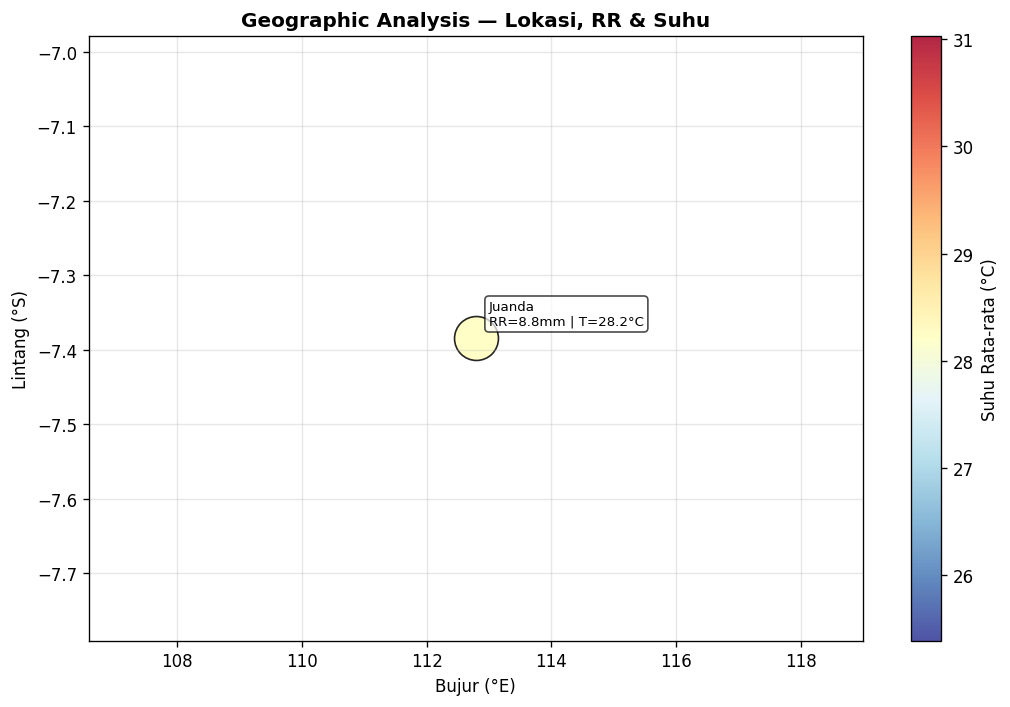

Geographic analysis selesai!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 15 — ANALYSIS: GEOGRAPHIC ANALYSIS                    ║
# ╚══════════════════════════════════════════════════════════════╝

print('='*60)
print('GEOGRAPHIC ANALYSIS')
print('='*60)

geo = df.groupby(['STASIUN','STASIUN_SHORT','LINTANG','BUJUR','ELEVASI_M']).agg(
    Total_RR  = ('RR_FILLED','sum'),
    Rata2_RR  = ('RR_FILLED','mean'),
    Max_RR    = ('RR_FILLED','max'),
    Rata2_T   = ('TAVG_FILLED','mean'),
    Max_TX    = ('TX_FILLED','max'),
    Rata2_RH  = ('RH_AVG_FILLED','mean'),
    Hari_Hujan= ('RR_FILLED', lambda x: (x > 0).sum())
).round(2).reset_index()

print(geo[['STASIUN_SHORT','LINTANG','BUJUR','ELEVASI_M',
           'Total_RR','Rata2_RR','Rata2_T','Rata2_RH','Hari_Hujan']].to_string(index=False))

# Peta geografis
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(geo['BUJUR'], geo['LINTANG'],
                s=geo['Total_RR'] / 5,
                c=geo['Rata2_T'], cmap='RdYlBu_r',
                alpha=0.85, edgecolors='black', linewidths=1)
for _, row in geo.iterrows():
    ax.annotate(
        f"{row['STASIUN_SHORT']}\nRR={row['Rata2_RR']:.1f}mm | T={row['Rata2_T']:.1f}°C",
        (row['BUJUR'], row['LINTANG']), fontsize=8,
        xytext=(8, 8), textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )
plt.colorbar(sc, ax=ax, label='Suhu Rata-rata (°C)')
ax.set_xlabel('Bujur (°E)')
ax.set_ylabel('Lintang (°S)')
ax.set_title('Geographic Analysis — Lokasi, RR & Suhu', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/visualisasi/geographic_analysis.png', bbox_inches='tight')
plt.show()
print('Geographic analysis selesai!')

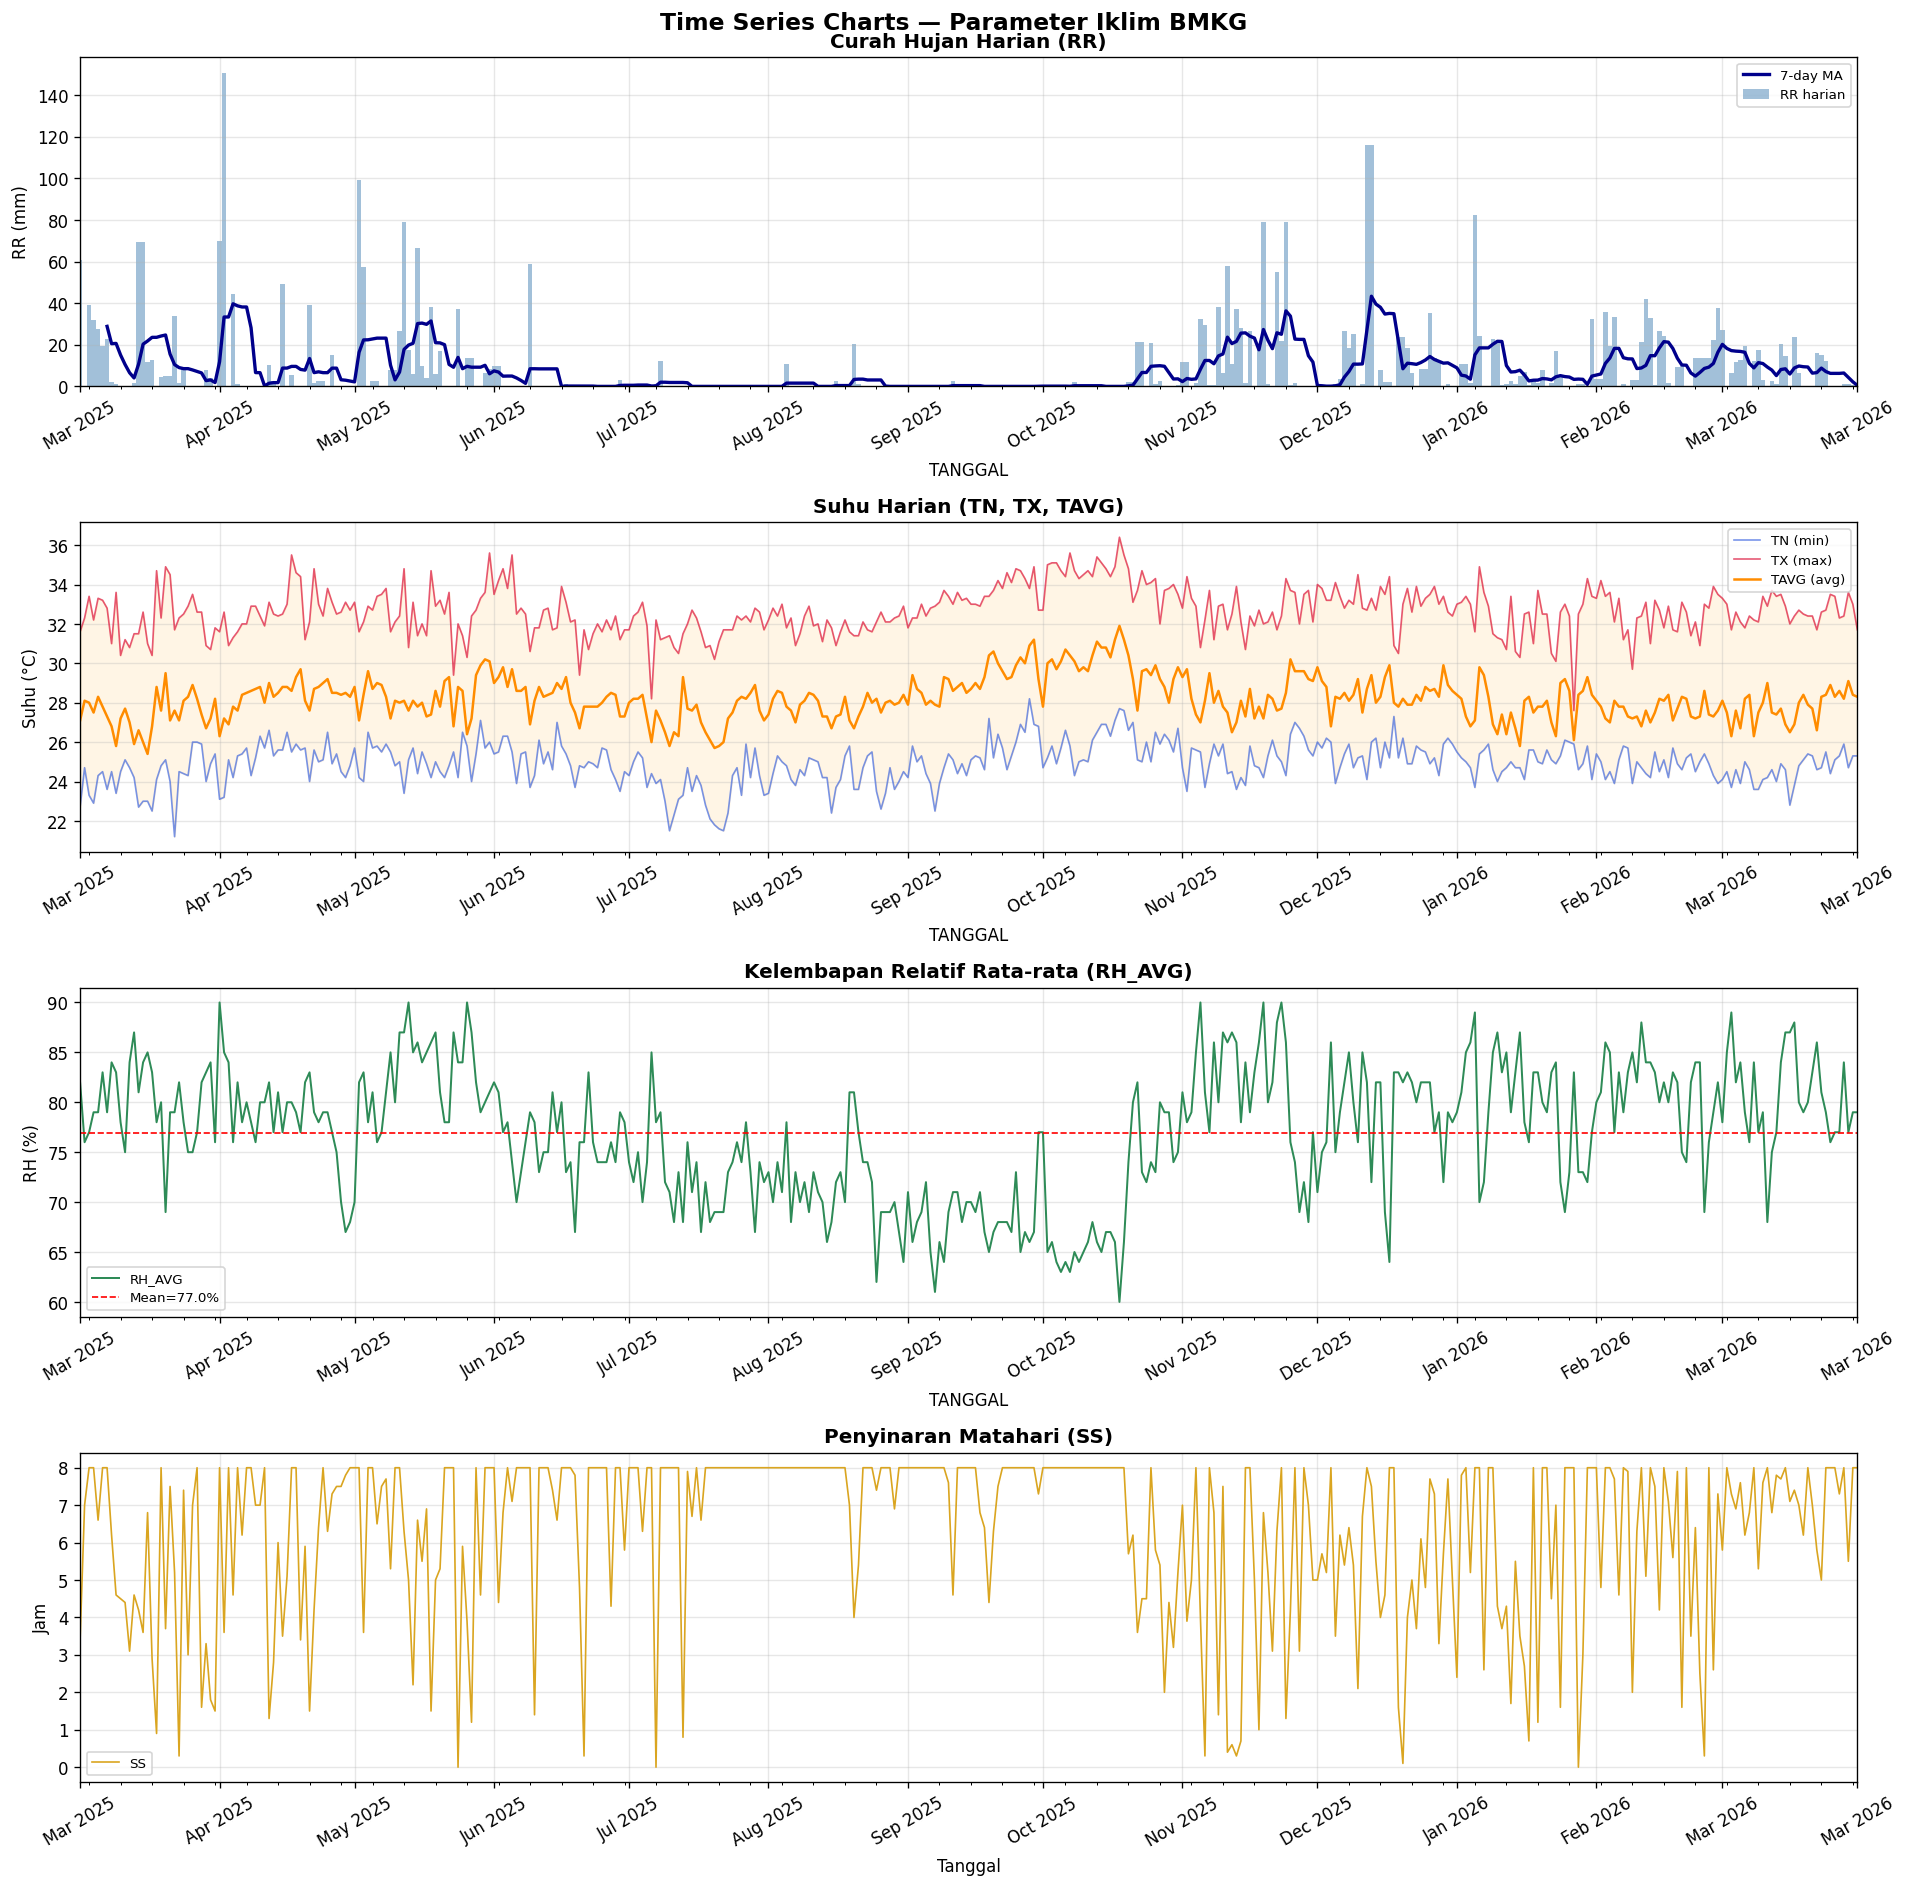

Time series charts selesai!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 16 — VISUALIZATIONS: TIME SERIES CHARTS               ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(4, 1, figsize=(16, 16))
fig.suptitle('Time Series Charts — Parameter Iklim BMKG', fontsize=14, fontweight='bold')

df_ts = df.sort_values('TANGGAL').set_index('TANGGAL')

# Plot 1: Curah Hujan harian + rolling 7 hari
axes[0].bar(df_ts.index, df_ts['RR_FILLED'], color='steelblue', alpha=0.5, width=1, label='RR harian')
df_ts['RR_FILLED'].rolling(7).mean().plot(ax=axes[0], color='darkblue', linewidth=2, label='7-day MA')
axes[0].set_title('Curah Hujan Harian (RR)')
axes[0].set_ylabel('RR (mm)')
axes[0].legend(fontsize=8)

# Plot 2: Suhu (TN, TX, TAVG)
df_ts['TN_FILLED'].plot( ax=axes[1], color='royalblue',  linewidth=1, label='TN (min)', alpha=0.7)
df_ts['TX_FILLED'].plot( ax=axes[1], color='crimson',    linewidth=1, label='TX (max)', alpha=0.7)
df_ts['TAVG_FILLED'].plot(ax=axes[1], color='darkorange', linewidth=1.5, label='TAVG (avg)')
axes[1].fill_between(df_ts.index, df_ts['TN_FILLED'], df_ts['TX_FILLED'], alpha=0.1, color='orange')
axes[1].set_title('Suhu Harian (TN, TX, TAVG)')
axes[1].set_ylabel('Suhu (°C)')
axes[1].legend(fontsize=8)

# Plot 3: Kelembapan
df_ts['RH_AVG_FILLED'].plot(ax=axes[2], color='seagreen', linewidth=1.2, label='RH_AVG')
axes[2].axhline(df['RH_AVG_FILLED'].mean(), color='red', linestyle='--', linewidth=1,
                label=f'Mean={df["RH_AVG_FILLED"].mean():.1f}%')
axes[2].set_title('Kelembapan Relatif Rata-rata (RH_AVG)')
axes[2].set_ylabel('RH (%)')
axes[2].legend(fontsize=8)

# Plot 4: Penyinaran matahari
df_ts['SS_FILLED'].plot(ax=axes[3], color='goldenrod', linewidth=1, label='SS')
axes[3].set_title('Penyinaran Matahari (SS)')
axes[3].set_ylabel('Jam')
axes[3].set_xlabel('Tanggal')
axes[3].legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/visualisasi/timeseries_charts.png', bbox_inches='tight')
plt.show()
print('Time series charts selesai!')

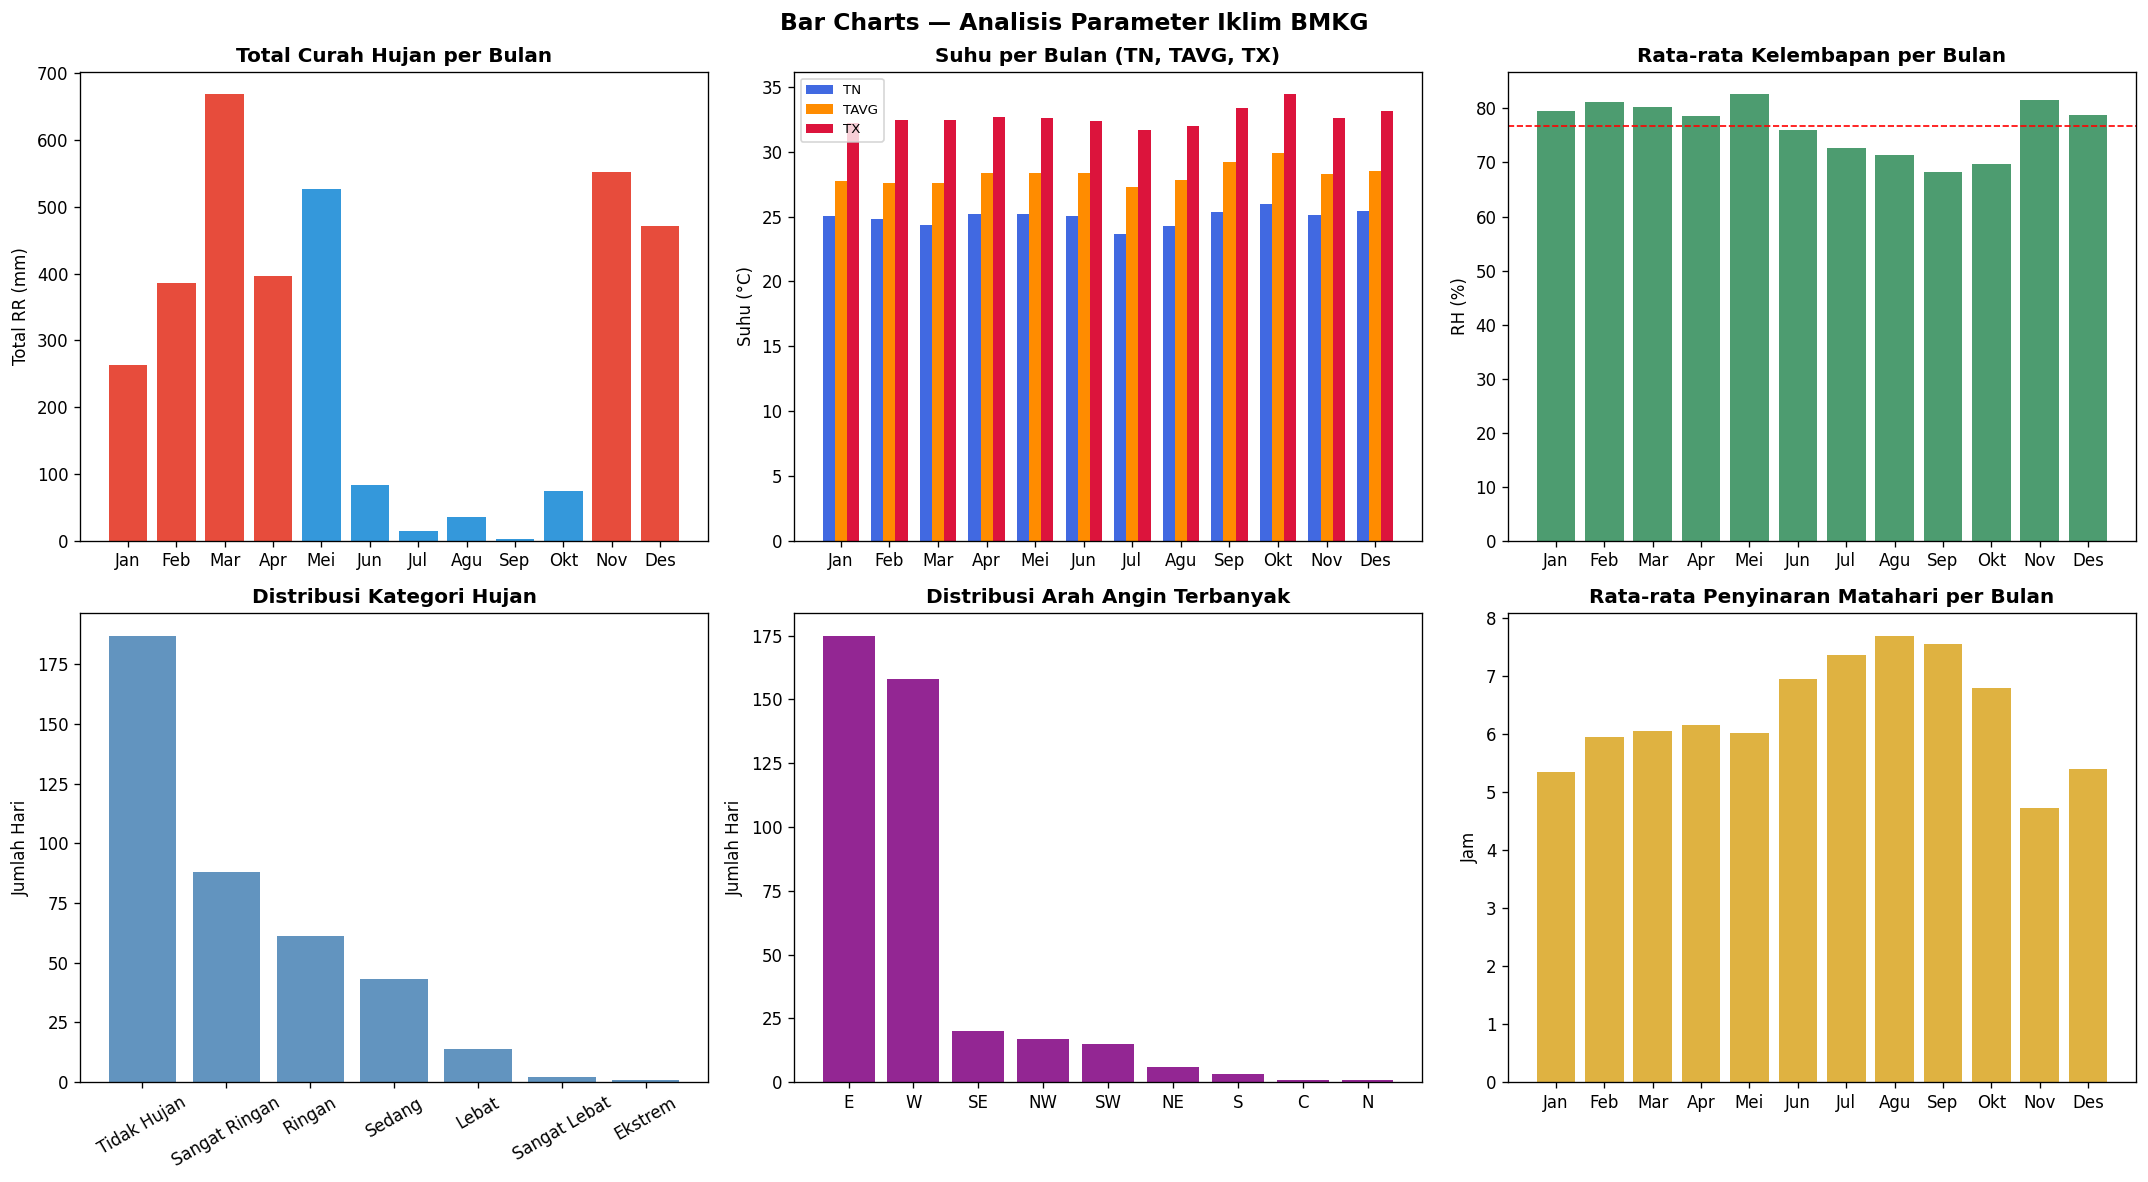

Bar charts selesai!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 17 — VISUALIZATIONS: BAR CHARTS                       ║
# ╚══════════════════════════════════════════════════════════════╝

bulan_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
             7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Bar Charts — Analisis Parameter Iklim BMKG', fontsize=14, fontweight='bold')

# Bar 1: Total RR per bulan
rr_bln = df.groupby('BULAN')['RR_FILLED'].sum()
colors_bln = ['#e74c3c' if b in [11,12,1,2,3,4] else '#3498db' for b in rr_bln.index]
axes[0,0].bar([bulan_map[b] for b in rr_bln.index], rr_bln.values, color=colors_bln)
axes[0,0].set_title('Total Curah Hujan per Bulan')
axes[0,0].set_ylabel('Total RR (mm)')

# Bar 2: Rata-rata suhu per bulan
t_bln = df.groupby('BULAN')[['TN_FILLED','TX_FILLED','TAVG_FILLED']].mean()
x = range(len(t_bln))
w = 0.25
axes[0,1].bar([i-w for i in x], t_bln['TN_FILLED'],  width=w, label='TN', color='royalblue')
axes[0,1].bar(x,                t_bln['TAVG_FILLED'], width=w, label='TAVG', color='darkorange')
axes[0,1].bar([i+w for i in x], t_bln['TX_FILLED'],  width=w, label='TX', color='crimson')
axes[0,1].set_xticks(list(x))
axes[0,1].set_xticklabels([bulan_map[b] for b in t_bln.index])
axes[0,1].set_title('Suhu per Bulan (TN, TAVG, TX)')
axes[0,1].set_ylabel('Suhu (°C)')
axes[0,1].legend(fontsize=8)

# Bar 3: Rata-rata kelembapan per bulan
rh_bln = df.groupby('BULAN')['RH_AVG_FILLED'].mean()
axes[0,2].bar([bulan_map[b] for b in rh_bln.index], rh_bln.values, color='seagreen', alpha=0.85)
axes[0,2].axhline(rh_bln.mean(), color='red', linestyle='--', linewidth=1)
axes[0,2].set_title('Rata-rata Kelembapan per Bulan')
axes[0,2].set_ylabel('RH (%)')

# Bar 4: Distribusi kategori hujan
kat_count = df['KATEGORI_HUJAN'].value_counts().sort_index()
axes[1,0].bar(kat_count.index.astype(str), kat_count.values, color='steelblue', alpha=0.85)
axes[1,0].set_title('Distribusi Kategori Hujan')
axes[1,0].set_ylabel('Jumlah Hari')
axes[1,0].tick_params(axis='x', rotation=30)

# Bar 5: Distribusi arah angin
angin = df['DDD_CAR'].value_counts().head(10)
axes[1,1].bar(angin.index, angin.values, color='purple', alpha=0.85)
axes[1,1].set_title('Distribusi Arah Angin Terbanyak')
axes[1,1].set_ylabel('Jumlah Hari')

# Bar 6: Penyinaran matahari per bulan
ss_bln = df.groupby('BULAN')['SS_FILLED'].mean()
axes[1,2].bar([bulan_map[b] for b in ss_bln.index], ss_bln.values, color='goldenrod', alpha=0.85)
axes[1,2].set_title('Rata-rata Penyinaran Matahari per Bulan')
axes[1,2].set_ylabel('Jam')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/visualisasi/bar_charts.png', bbox_inches='tight')
plt.show()
print('Bar charts selesai!')

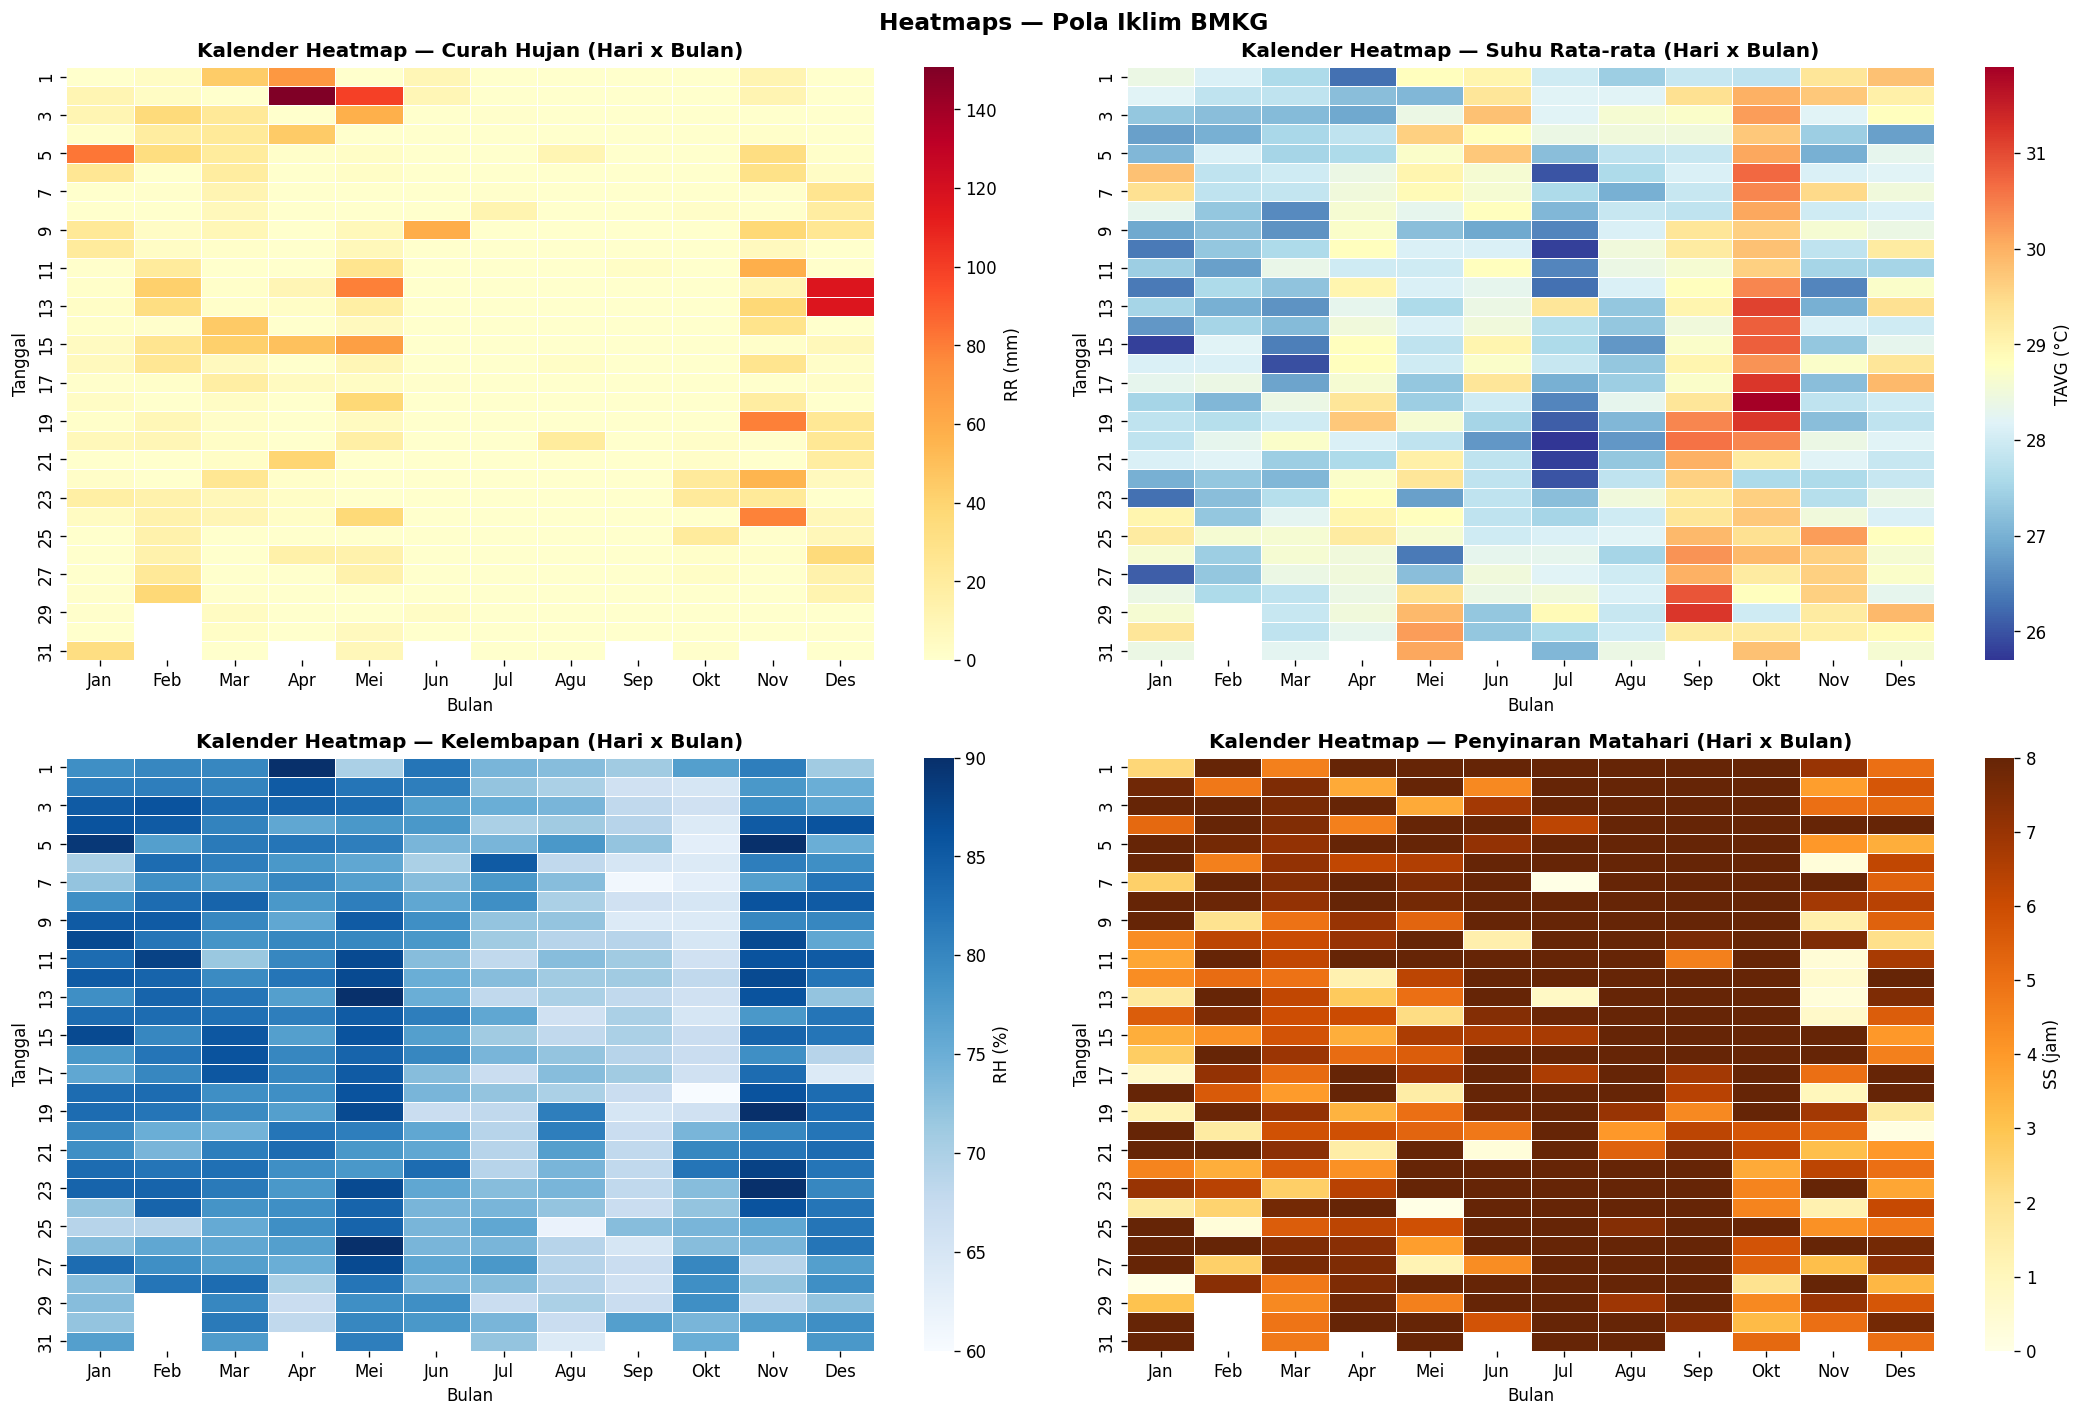

Heatmaps selesai!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 18 — VISUALIZATIONS: HEATMAPS                         ║
# ╚══════════════════════════════════════════════════════════════╝

bulan_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
             7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Heatmaps — Pola Iklim BMKG', fontsize=14, fontweight='bold')

# Heatmap 1: Rata-rata RR per (Hari x Bulan) — kalender
pivot_rr = df.pivot_table(values='RR_FILLED', index='HARI', columns='BULAN', aggfunc='mean')
pivot_rr.columns = [bulan_map[c] for c in pivot_rr.columns]
sns.heatmap(pivot_rr, ax=axes[0,0], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label':'RR (mm)'})
axes[0,0].set_title('Kalender Heatmap — Curah Hujan (Hari x Bulan)')
axes[0,0].set_xlabel('Bulan')
axes[0,0].set_ylabel('Tanggal')

# Heatmap 2: Rata-rata Suhu per (Hari x Bulan)
pivot_t = df.pivot_table(values='TAVG_FILLED', index='HARI', columns='BULAN', aggfunc='mean')
pivot_t.columns = [bulan_map[c] for c in pivot_t.columns]
sns.heatmap(pivot_t, ax=axes[0,1], cmap='RdYlBu_r', linewidths=0.3,
            cbar_kws={'label':'TAVG (°C)'}, annot=False)
axes[0,1].set_title('Kalender Heatmap — Suhu Rata-rata (Hari x Bulan)')
axes[0,1].set_xlabel('Bulan')
axes[0,1].set_ylabel('Tanggal')

# Heatmap 3: Rata-rata RH per (Hari x Bulan)
pivot_rh = df.pivot_table(values='RH_AVG_FILLED', index='HARI', columns='BULAN', aggfunc='mean')
pivot_rh.columns = [bulan_map[c] for c in pivot_rh.columns]
sns.heatmap(pivot_rh, ax=axes[1,0], cmap='Blues', linewidths=0.3,
            cbar_kws={'label':'RH (%)'})
axes[1,0].set_title('Kalender Heatmap — Kelembapan (Hari x Bulan)')
axes[1,0].set_xlabel('Bulan')
axes[1,0].set_ylabel('Tanggal')

# Heatmap 4: Rata-rata SS per (Hari x Bulan)
pivot_ss = df.pivot_table(values='SS_FILLED', index='HARI', columns='BULAN', aggfunc='mean')
pivot_ss.columns = [bulan_map[c] for c in pivot_ss.columns]
sns.heatmap(pivot_ss, ax=axes[1,1], cmap='YlOrBr', linewidths=0.3,
            cbar_kws={'label':'SS (jam)'})
axes[1,1].set_title('Kalender Heatmap — Penyinaran Matahari (Hari x Bulan)')
axes[1,1].set_xlabel('Bulan')
axes[1,1].set_ylabel('Tanggal')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/visualisasi/heatmaps.png', bbox_inches='tight')
plt.show()
print('Heatmaps selesai!')

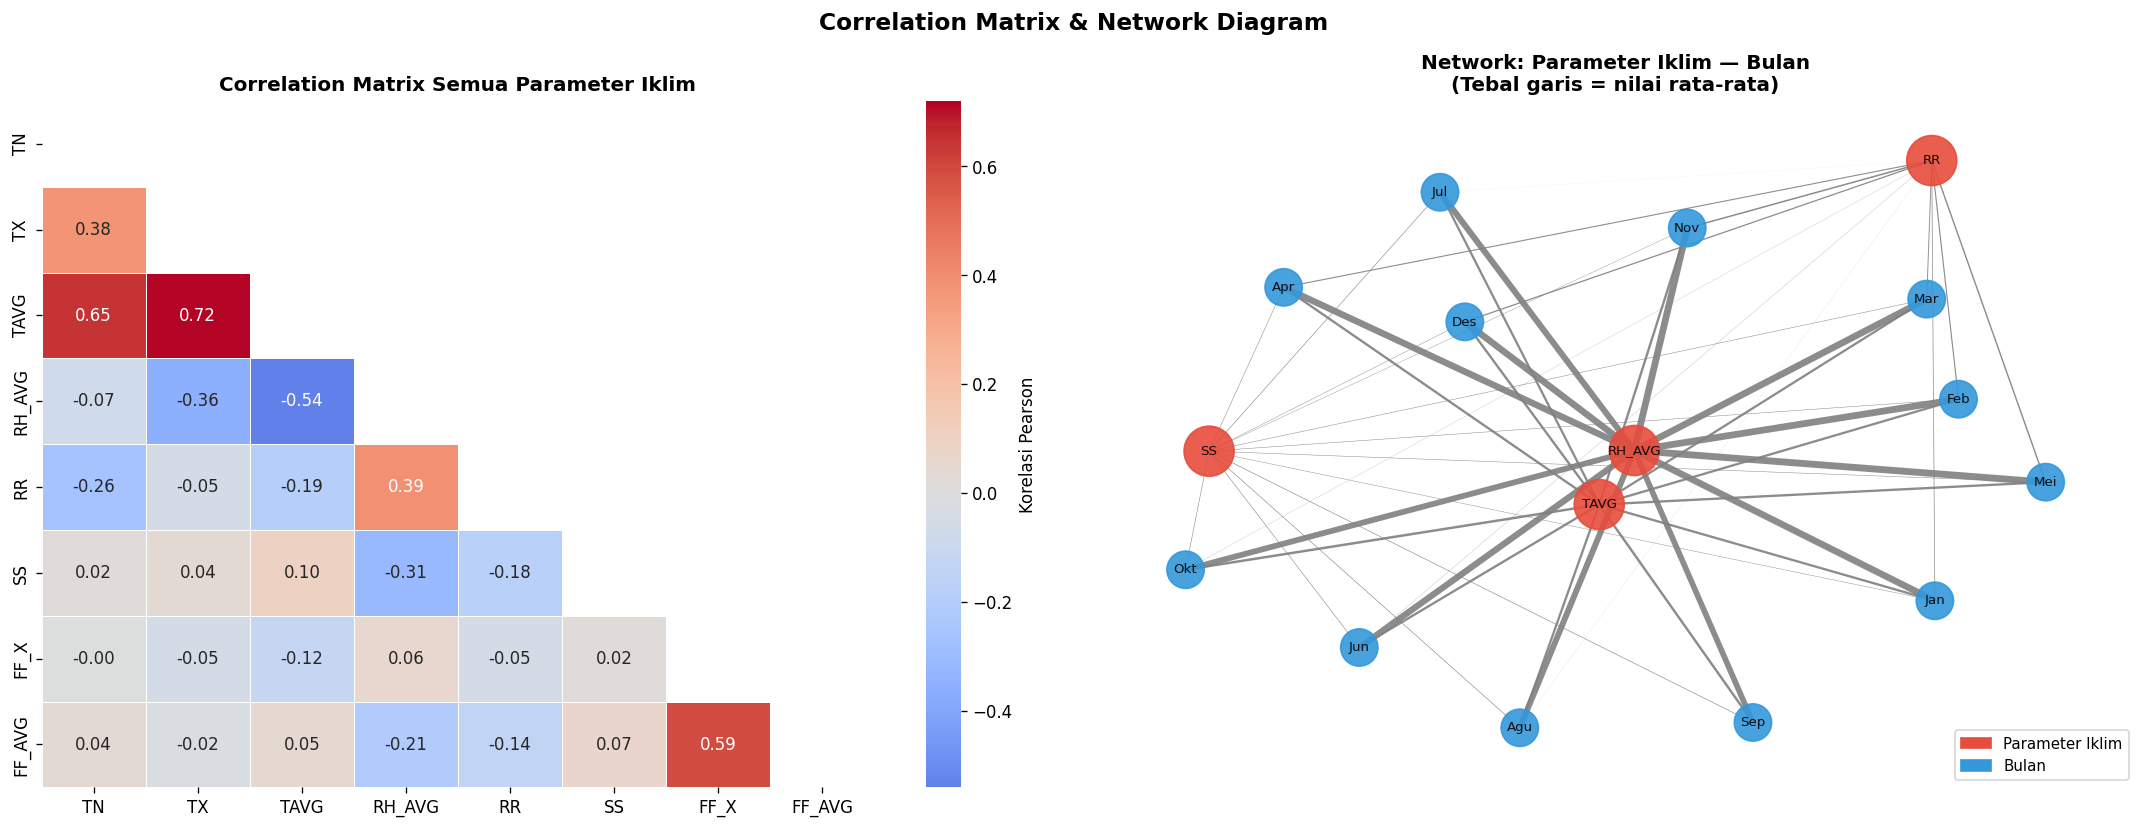

Correlation & Network diagram selesai!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 19 — VISUALIZATIONS: CORRELATION & NETWORK DIAGRAM    ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlation Matrix & Network Diagram', fontsize=14, fontweight='bold')

# --- Correlation Matrix (semua parameter) ---
corr_cols = ['TN_FILLED','TX_FILLED','TAVG_FILLED','RH_AVG_FILLED',
             'RR_FILLED','SS_FILLED','FF_X_FILLED','FF_AVG_FILLED']
corr_labels = ['TN','TX','TAVG','RH_AVG','RR','SS','FF_X','FF_AVG']
corr_matrix = df[corr_cols].corr().round(2)
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'label':'Korelasi Pearson'})
axes[0].set_title('Correlation Matrix Semua Parameter Iklim')

# --- Network Diagram: Hubungan Parameter - Bulan ---
G = nx.Graph()

bulan_map_s = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
               7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'}

params_net  = ['RR','TAVG','RH_AVG','SS']
for p in params_net:
    G.add_node(p, node_type='parameter')
for b in df['BULAN'].unique():
    G.add_node(bulan_map_s[b], node_type='bulan')

for p in params_net:
    col = f'{p}_FILLED'
    for b in df['BULAN'].unique():
        val = df[df['BULAN'] == b][col].mean()
        if not np.isnan(val):
            G.add_edge(p, bulan_map_s[b], weight=round(val, 1))

pos         = nx.spring_layout(G, seed=42, k=2)
node_colors = ['#e74c3c' if G.nodes[n].get('node_type') == 'parameter' else '#3498db' for n in G.nodes]
node_sizes  = [900 if G.nodes[n].get('node_type') == 'parameter' else 500 for n in G.nodes]
weights     = [G[u][v]['weight'] / 20 for u, v in G.edges]

nx.draw_networkx(G, pos, ax=axes[1],
                 node_color=node_colors, node_size=node_sizes,
                 width=weights, edge_color='gray',
                 font_size=8, alpha=0.9)
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#e74c3c', label='Parameter Iklim'),
    Patch(color='#3498db', label='Bulan')
], loc='lower right', fontsize=9)
axes[1].set_title('Network: Parameter Iklim — Bulan\n(Tebal garis = nilai rata-rata)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/visualisasi/correlation_network.png', bbox_inches='tight')
plt.show()
print('Correlation & Network diagram selesai!')

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 20 — EXPORT SEMUA HASIL KE EXCEL                      ║
# ╚══════════════════════════════════════════════════════════════╝

output_path = f'{PROJECT_DIR}/output/BMKG_Dataset_Final.xlsx'

export_cols = ['TANGGAL','TAHUN','BULAN','NAMA_BULAN','HARI','MUSIM',
               'STASIUN','STASIUN_SHORT','ID_WMO','LINTANG','BUJUR','ELEVASI_M',
               'TN','TX','TAVG','RH_AVG','RR','SS','FF_X','DDD_X','FF_AVG','DDD_CAR',
               'TN_FILLED','TX_FILLED','TAVG_FILLED','RH_AVG_FILLED',
               'RR_FILLED','SS_FILLED','FF_X_FILLED','FF_AVG_FILLED',
               'RR_IMPUTED','KATEGORI_HUJAN','KATEGORI_SUHU']

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    df_raw.to_excel(writer, sheet_name='1_Raw_Merged', index=False)
    df[export_cols].to_excel(writer, sheet_name='2_Clean_Data', index=False)

    mv_report = pd.DataFrame({
        'Kolom'           : ['RR','TN','TX','TAVG','RH_AVG','SS','FF_X','FF_AVG'],
        'Missing Sebelum' : [df['RR'].isna().sum(), df['TN'].isna().sum(),
                             df['TX'].isna().sum(), df['TAVG'].isna().sum(),
                             df['RH_AVG'].isna().sum(), df['SS'].isna().sum(),
                             df['FF_X'].isna().sum(), df['FF_AVG'].isna().sum()],
        'Metode'          : ['Forward fill -> Backward fill -> Median per Bulan'] * 8,
        'Missing Sesudah' : [df[f'{c}_FILLED'].isna().sum() for c in
                             ['RR','TN','TX','TAVG','RH_AVG','SS','FF_X','FF_AVG']]
    })
    mv_report.to_excel(writer, sheet_name='3_Missing_Values', index=False)

    monthly.to_excel(writer, sheet_name='4_EDA_Monthly', index=False)
    trend_monthly[['LABEL'] + trend_params].to_excel(writer, sheet_name='5_Trend_Analysis', index=False)
    musim_stat.to_excel(writer, sheet_name='6_Seasonal_Analysis')
    anomali_rr[['TANGGAL','STASIUN_SHORT','RR_FILLED','RR_FILLED_Z','KATEGORI_HUJAN']]\
        .to_excel(writer, sheet_name='7_Anomaly_Events', index=False)
    geo.to_excel(writer, sheet_name='8_Geographic', index=False)
    corr_matrix.to_excel(writer, sheet_name='9_Correlation_Matrix')

print(f'File Excel tersimpan:')
print(f'  {output_path}')
print(f'\nSheet tersedia:')
for s in ['1_Raw_Merged','2_Clean_Data','3_Missing_Values','4_EDA_Monthly',
          '5_Trend_Analysis','6_Seasonal_Analysis','7_Anomaly_Events',
          '8_Geographic','9_Correlation_Matrix']:
    print(f'  {s}')

print(f'\nVisualisasi tersimpan di: {PROJECT_DIR}/visualisasi/')
for v in ['eda_distribution.png','eda_patterns.png','geographic_analysis.png',
          'timeseries_charts.png','bar_charts.png','heatmaps.png','correlation_network.png']:
    print(f'  {v}')

File Excel tersimpan:
  /content/drive/MyDrive/big-data-uts/output/BMKG_Dataset_Final.xlsx

Sheet tersedia:
  1_Raw_Merged
  2_Clean_Data
  3_Missing_Values
  4_EDA_Monthly
  5_Trend_Analysis
  6_Seasonal_Analysis
  7_Anomaly_Events
  8_Geographic
  9_Correlation_Matrix

Visualisasi tersimpan di: /content/drive/MyDrive/big-data-uts/visualisasi/
  eda_distribution.png
  eda_patterns.png
  geographic_analysis.png
  timeseries_charts.png
  bar_charts.png
  heatmaps.png
  correlation_network.png
